In [1]:
import warnings 
warnings.filterwarnings("ignore")
from typing import Annotated,Literal,Sequence,TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.pydantic_v1 import BaseModel,Field
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition,ToolNode
from langgraph.graph import END,StateGraph,START


/home/abhishek/daily/tasks/langchain/lang-env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
import os

os.environ["LANGCHAIN_TRACING_V2"]='true'
os.environ["LANGCHAIN_ENDPOINT"]="https://api.smith.langchain.com"

In [3]:
import dotenv

dotenv.load_dotenv()

True

In [4]:
import ollama
ollama.pull("nomic-embed-text")

ProgressResponse(status='success', completed=None, total=None, digest=None)

In [5]:
from langchain_ollama import OllamaEmbeddings
embeddings=OllamaEmbeddings(model="nomic-embed-text")
from langchain_groq import ChatGroq
llm=ChatGroq(model="Gemma2-9b-It")

In [6]:
urls=[
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/'
]

In [7]:
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist]
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=25)
doc_splits=text_splitter.split_documents(docs_list)

In [8]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings
)

In [9]:
retriever=vectorstore.as_retriever()
retrieval_tool=create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents and prompt engineering")

In [10]:
from langchain_core.tools import tool
@tool
def off_topic():
    """Catch all Questions NOT related to Lilian  Weng blog posts on LLM agents and prompt engineering"""
    return "Forbidden - do not respond to the user"


tools = [retrieval_tool]

In [11]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [12]:
from langchain_core.messages import ToolMessage

In [13]:
from langchain_core.prompts import ChatPromptTemplate

routing_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a router. Decide if this user question is about Lilian Weng's blog posts on LLM agents and prompt engineering. Respond with 'yes' or 'no'."),
    ("human", "{question}")
])
def should_use_tool(question: str) -> bool:
    router_llm = llm  
    router_chain = routing_prompt | router_llm
    result = router_chain.invoke({"question": question})
    return "yes" in result.content.lower()

In [ ]:
def agent(state: AgentState):
    messages = state["messages"]
    last_user_message = messages[-1].content

    if should_use_tool(last_user_message):
        model = llm.bind_tools(tools)
    else:
        model = llm  

    response = model.invoke(messages)
    return {"messages": [response]}


def llm_response(state: AgentState):
    messages = state["messages"]
    response = llm.invoke(messages)  
    return {"messages": [response]}

def should_continue(state: AgentState) -> Literal["tools", "llm_response"]:
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tools"
    return "llm_response"

In [15]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))
workflow.add_node("llm_response", llm_response)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", END)
workflow.add_edge("llm_response", END)

graph = workflow.compile()

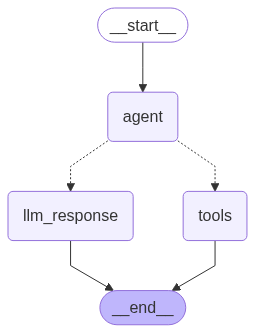

In [16]:
graph

In [17]:
graph.invoke({
    "messages": [HumanMessage(content="What did Lilian Weng say about ReAct agents?")]
})

{'messages': [HumanMessage(content='What did Lilian Weng say about ReAct agents?', additional_kwargs={}, response_metadata={}, id='e8c1e04f-c81e-4ecb-becd-955f7b3dc14d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fh5mqrkw8', 'function': {'arguments': '{"query":"ReAct agents"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 975, 'total_tokens': 1061, 'completion_time': 0.156363636, 'prompt_time': 0.034460112, 'queue_time': 0.248503158, 'total_time': 0.190823748}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--7e2332fa-5b5c-4aef-b9a2-bb6b1ffc3775-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'ReAct agents'}, 'id': 'fh5mqrkw8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 975, 'output_tokens': 86, 'total_tokens': 1061}),
  ToolMessage(content="In both experiments on knowl

In [18]:
graph.invoke({
    "messages": [HumanMessage(content="Where is delhi?")]
})

{'messages': [HumanMessage(content='Where is delhi?', additional_kwargs={}, response_metadata={}, id='6d4042c9-e297-42fc-af5d-43e92eacb4fa'),
  AIMessage(content="Delhi is located in **northern India**. \n\nMore specifically:\n\n* It's the capital of **India**.\n* It's situated on the **banks of the Yamuna River**.\n* It's near the **Indo-Gangetic Plain**.\n\n\nLet me know if you'd like more details about Delhi's location!\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 13, 'total_tokens': 88, 'completion_time': 0.136363636, 'prompt_time': 0.001916187, 'queue_time': 0.24390338199999997, 'total_time': 0.138279823}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--9ccdcb67-9703-4a1a-a1c6-c6cf43c18b67-0', usage_metadata={'input_tokens': 13, 'output_tokens': 75, 'total_tokens': 88}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {

In [19]:
graph.invoke({
    "messages": [HumanMessage(content="is india in asia?")]
})

{'messages': [HumanMessage(content='is india in asia?', additional_kwargs={}, response_metadata={}, id='b40a7799-63f4-4000-ab93-884bcca9acfd'),
  AIMessage(content='Yes, India is located in **South Asia**.  \n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 14, 'total_tokens': 28, 'completion_time': 0.025454545, 'prompt_time': 0.001911457, 'queue_time': 0.244446092, 'total_time': 0.027366002}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--ef8004dd-2c77-4551-89dc-de97e50709ea-0', usage_metadata={'input_tokens': 14, 'output_tokens': 14, 'total_tokens': 28}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 26, 'total_tokens': 28, 'completion_time': 0.003756924, 'prompt_time': 0.002114287, 'queue_time': -9223372036.85689, 'total_time': 0.005871211}, 'model_name': 'Gemma2-9b-It', 'system_fin

In [20]:
graph.invoke({
    "messages": [HumanMessage(content="What are autonomous agents?")]
})

{'messages': [HumanMessage(content='What are autonomous agents?', additional_kwargs={}, response_metadata={}, id='7fddb08a-775a-4446-a0b1-68f44b7c83a3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kknmtyqf1', 'function': {'arguments': '{"query":"autonomous agents"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 969, 'total_tokens': 1054, 'completion_time': 0.154545455, 'prompt_time': 0.040602712, 'queue_time': 0.24546295100000004, 'total_time': 0.195148167}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--aa5631c6-1432-424e-ae2e-60d7002b97c4-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'autonomous agents'}, 'id': 'kknmtyqf1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 969, 'output_tokens': 85, 'total_tokens': 1054}),
  ToolMessage(content='Agent System Overview#\nIn 

In [21]:
graph.invoke({
    "messages": [HumanMessage(content="What is prompt engineering?")]
})

{'messages': [HumanMessage(content='What is prompt engineering?', additional_kwargs={}, response_metadata={}, id='0d52e0a9-ec8e-4ef1-b8dd-2fa30af7adba'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ytnx3s78g', 'function': {'arguments': '{"query":"What is prompt engineering?"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 969, 'total_tokens': 1055, 'completion_time': 0.156363636, 'prompt_time': 0.034124603, 'queue_time': 0.246806047, 'total_time': 0.190488239}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--96870744-3852-44a1-9af7-71391069f9e6-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'What is prompt engineering?'}, 'id': 'ytnx3s78g', 'type': 'tool_call'}], usage_metadata={'input_tokens': 969, 'output_tokens': 86, 'total_tokens': 1055}),
  ToolMessage(content='Prompt Engineer

{'messages': [ToolMessage(content='Forbidden - do not respond to the user', name='off_topic', tool_call_id='qa4ajhr5y'),
  AIMessage(content='</tool-use>', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 1073, 'total_tokens': 1080, 'completion_time': 0.012727273, 'prompt_time': 0.046425689, 'queue_time': 0.24661346100000003, 'total_time': 0.059152962}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--719fbad1-673f-4ecf-8c1b-6192b5f62614-0', usage_metadata={'input_tokens': 1073, 'output_tokens': 7, 'total_tokens': 1080})]}

{'messages': [HumanMessage(content='is india inside asia?', additional_kwargs={}, response_metadata={}, id='3bf0c8df-c623-45da-acfe-6a1c8ade45c8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't9qgvtzkm', 'function': {'arguments': '{}', 'name': 'off_topic'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 1051, 'total_tokens': 1123, 'completion_time': 0.130909091, 'prompt_time': 0.037176509, 'queue_time': 0.25425611099999995, 'total_time': 0.1680856}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4497d887-fab2-47bc-b6a3-c931b9d530c2-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 't9qgvtzkm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1051, 'output_tokens': 72, 'total_tokens': 1123}),
  ToolMessage(content='Forbidden - do not respond to the user', name='off_topic', id='3959317e-dc00-4b76-b69c-35eb7656790e', tool_c